In [1]:
import Agents

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
NA = 100
NB = 1
N = NA+NB

initialize_money = 'set'
M = 100.

n = 2

QA1 = 1.
QA2 = 0.

QB1 = 0.
QB2 = 0.

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([0, 0])
qB = np.array([0, 0])

cA = np.array([0, 0])
cB = np.array([100., 0])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'set'

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 1.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

In [3]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [4]:
# Initialize agent asking and bidding prices

In [5]:
for agent in agentA_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_A_0, p2buy_A_0]
        agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
for agent in agentB_list:

    if initialize_prices=='random':

        agent.p_buy  = np.random.uniform(agent.M, size=n)
        agent.p_sell = np.random.uniform(agent.M, size=n)

    else:
        agent.p_buy  = [p1buy_B_0, p2buy_B_0]
        agent.p_sell = [p1sell_B_0, p2sell_B_0]

In [6]:
### Simple Continuous Double Auction ###

In [7]:
def determine_market_quantity(agent):
    S = agent.Q - agent.D

    scaling_mask = S > 0
    S[scaling_mask] = gamma*S[scaling_mask]

    return S

def softmax(X):
    
    prob = np.exp(X)/(np.exp(X).sum())
    
    return prob

def transaction(i, buyer_agent, buyer_index, seller_agent, seller_index):

    S_buyer   = -agent_data[buyer_index, 2, i]
    buyer_bid  = agent_data[buyer_index, 0, i]
    buyer_M = agent_Mdata[buyer_index]
    
    # Check that the buyer has enough money to purchase S_buyer, else 
    if buyer_bid*S_buyer > buyer_M:
        S_buyer = buyer_M/buyer_bid
    
    S_seller   = agent_data[seller_index, 2, i]
    seller_ask = agent_data[seller_index, 1, i]
    
    # Come to agreement
    # Can't buy more than the seller has, or the buyer wants
    S_exchanged = min(S_buyer, S_seller)
    # Select random price between the bidding and asking price.
    p_exchanged = random.uniform(seller_ask, buyer_bid)
    dM_exchanged = p_exchanged * S_exchanged
    # Since the bidding price is larger than the asking price, then p_exchanged*S_exchanged will still <= buyer M

    # Update the agents' states
    buyer_agent.Q[i]  = buyer_agent.Q[i]  + S_exchanged
    seller_agent.Q[i] = seller_agent.Q[i] - S_exchanged

    buyer_agent.M  = buyer_agent.M  - dM_exchanged
    seller_agent.M = seller_agent.M + dM_exchanged


    # Update the agent_data numpy array
    agent_data[buyer_index,  2, i] += S_exchanged
    agent_data[seller_index, 2, i] -= S_exchanged
    
    agent_Mdata[buyer_index]  = buyer_agent.M
    agent_Mdata[seller_index] = seller_agent.M
    
    return p_exchanged, S_exchanged, S_exchanged/S_buyer, S_exchanged/S_seller # S_buyer will be adjusted if they don't have the money


In [8]:
def update_prices(i, buyer_index, seller_index, transaction_successful):

    delta_bidding_price = np.random.uniform(0, [bidding_theta]*Nm)
    delta_asking_price  = np.random.uniform(0, [asking_theta]*Nm)    

    if transaction_successful:

        #### Buyers ####
        # The selected buyer will decrease their bid for next time
        agent_data[buyer_index, 0, i] *= (1.0 - delta_bidding_price[buyer_index])

        # The non selected buyers will increase their bids
        non_selected_buyers_mask = buyers_mask
        non_selected_buyers_mask[buyer_index] = False # This will update the buyers_mask array
        agent_data[non_selected_buyers_mask, 0, i] *= (1.0 + delta_bidding_price[non_selected_buyers_mask])

        #### Sellers ####
        # The selected seller will increase their ask for next time
        agent_data[seller_index, 1, i] *= (1.0 + delta_asking_price[seller_index])

        # The non selected sellers will decrease their asks
        non_selected_sellers_mask = sellers_mask
        non_selected_sellers_mask[seller_index] = False # This will update the sellers_mask array
        agent_data[non_selected_sellers_mask, 1, i] *= (1.0 - delta_asking_price[non_selected_sellers_mask])

    else:

        #### Buyers ####
        # No transaction occurs, so all buyers will increase prices
        agent_data[buyers_mask, 0, i] *= (1.0 + delta_bidding_price[buyers_mask])

        #### Sellers ####
        # No transaction occurs, so all selelrs will decrease their prices
        agent_data[sellers_mask, 0, i] *= (1.0 - delta_asking_price[sellers_mask])

    

In [9]:
Nproducts = n #2
max_tries = 100

ExchangeDict = {agent : 2 for agent in agent_list}

# Number of agents in the market
Nm = len(ExchangeDict)

M_min = 0.01 # Agent exists market if their money amount is less than this
gamma = 1
assert gamma <= 1

theta = 0.1 # [0, inf) Max proportional increase/decrease in prices
assert theta >= 0

bidding_theta = theta 
asking_theta = theta

# Create list of agents in market
exchanging_agent_list = np.array([agent for agent in ExchangeDict.keys()])
agent_mapping = {agent_obj: i for i,agent_obj in enumerate(ExchangeDict.keys())}

# Create numpy array of agent data
agent_data = np.array([[agent.p_buy, agent.p_sell, determine_market_quantity(agent)] for agent in ExchangeDict.keys()]) # prices and quantity per commodity
agent_Mdata = np.array([agent.M for agent in ExchangeDict.keys()]) # Money

uncleared_commodities = list(range(Nproducts))



In [10]:
#agent_data, uncleared_commodities

In [11]:
trial_data = []
trial_Mdata = []
trial_buyer = []
trial_seller = []
trial_price = []
n_tries = 0

trial_data.append(agent_data.copy())

In [12]:
while (len(uncleared_commodities) > 0) and (n_tries < max_tries):
    
    #print()
    #print(n_tries)

    # For trial, pick random commodity
    i = random.choice(uncleared_commodities) # commodity i

    agent_data_i = agent_data[:,:,i]

    # Create mask for buyers and select their data
    # Eligible buyers have a negative surplus, and have money to spend
    buyers_mask = (agent_data_i[:, 2] < 0) & (agent_Mdata > M_min)
    buyers_data_i = agent_data_i[buyers_mask]

    # Creat mask for sellers and select their data
    sellers_mask = agent_data_i[:, 2] > 0
    sellers_data_i = agent_data_i[sellers_mask]
    
    # If there are no buyers or sellers for commodity i, then this commodity is cleared
    if (buyers_mask.sum() == 0) or (sellers_mask.sum() == 0):
        uncleared_commodities.remove(i)
        
    else:
        # Continue with commodity

        # Using the bidding and asking prices, select a buyer, seller pair for this trial
        # The buyers, sellers are selected with probabilities related to their prices. Use softmax for this
        bidding_prices_i = buyers_data_i[:,0]
        asking_prices_i  = sellers_data_i[:,1]
        softmax_bids = scipy.special.softmax(bidding_prices_i) #scipy function avoids overflow errors
        softmax_asks = scipy.special.softmax(-asking_prices_i)

        buyer_agent  = np.random.choice(exchanging_agent_list[buyers_mask],  p=softmax_bids)
        buyer_index = agent_mapping[buyer_agent]

        seller_agent = np.random.choice(exchanging_agent_list[sellers_mask], p=softmax_asks)
        seller_index = agent_mapping[seller_agent]

        # Check if the selected buyer and seller can make a transaction
        buyer_bid  = agent_data_i[buyer_index,  0]
        seller_ask = agent_data_i[seller_index, 1]

        if buyer_bid >= seller_ask:

            # Transaction
            #print('Transaction')
            p, S_exchanged, buyer_eff, seller_eff = transaction(i, buyer_agent, buyer_index, seller_agent, seller_index)
            transaction_successful = True

        else:
            # prices change?
            transaction_successful = False
            p = np.nan
            #print('No Transaction')

        update_prices(i, buyer_index, seller_index, transaction_successful)

        trial_data.append(agent_data.copy())
        trial_Mdata.append(agent_Mdata.copy())
        trial_buyer.append(buyer_index)
        trial_seller.append(seller_index)
        trial_price.append(p) # assuming all are for i = 0
        
        n_tries += 1
        
trial_data = np.array(trial_data)
trial_Mdata = np.array(trial_Mdata)

In [13]:
uncleared_commodities

[]

In [14]:
n_tries, max_tries

(116, 500)

In [15]:
#trial_buyer

In [16]:
#trial_seller

In [17]:
#trial_price

In [18]:
#buyers_mask

In [19]:
#trial_data

In [20]:
#trial_data[:,:,:,0]

In [21]:
i = 0
asking_prices = trial_data[:, 0:NA, 1, i]
mean_asks = asking_prices.mean(axis=1)

supply = trial_data[:, 0:NA, 2, i]
total_supply = supply.sum(axis=1)


In [22]:
bidding_prices = trial_data[:, NA:NA+NB, 0, i]
mean_bids = bidding_prices.mean(axis=1)

demand = -trial_data[:, NA:NA+NB, 2, i]
total_demand = demand.sum(axis=1)

In [23]:
seller_money = trial_Mdata[:, 0:NA]
buyer_money = trial_Mdata[:, NA:NA+NB]
buyer_money2 = bidding_prices*demand

In [24]:
#[supply[t, trial_buyer[t]-NB] for t in range(len(trial_buyer))]

In [25]:
trial_buyer[0] - NA

0

In [26]:
buyer_bids = [bidding_prices[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]
buyer_demand = [demand[t, trial_buyer[t]-NA] for t in range(len(trial_buyer))]

In [27]:
seller_asks = [asking_prices[t, trial_seller[t]] for t in range(len(trial_seller))]
seller_supply = [supply[t, trial_seller[t]] for t in range(len(trial_seller))]

Even though there is only one buyer, they still increase their prices because they want 10, but only get 1 at each transaction (because each seller only has one item)

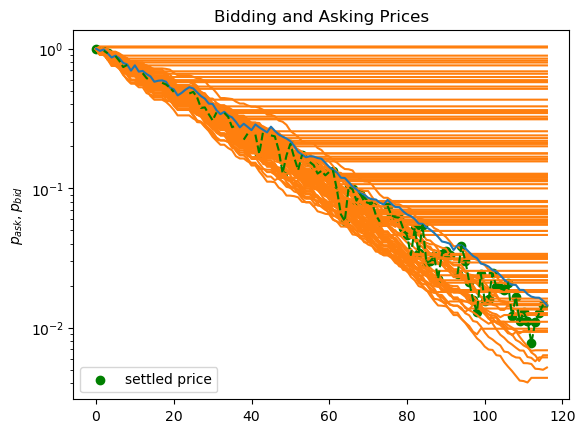

In [28]:
plt.plot(asking_prices, c='C1')
#plt.scatter(x=range(len(seller_asks)), y=seller_asks, c='C1', label='sellers')

plt.plot(bidding_prices, c='C0')
#plt.scatter(x=range(len(buyer_bids)), y=buyer_bids, c='C0', label='buyers')

plt.plot(trial_price, c='green', ls='--')
plt.scatter(x=range(len(trial_price)), y=trial_price, c='green', label='settled price')

plt.ylabel('$p_{ask}, p_{bid}$')
plt.title('Bidding and Asking Prices')
plt.legend()

plt.yscale('log')

Text(0, 0.5, '$S^{\\sigma}$')

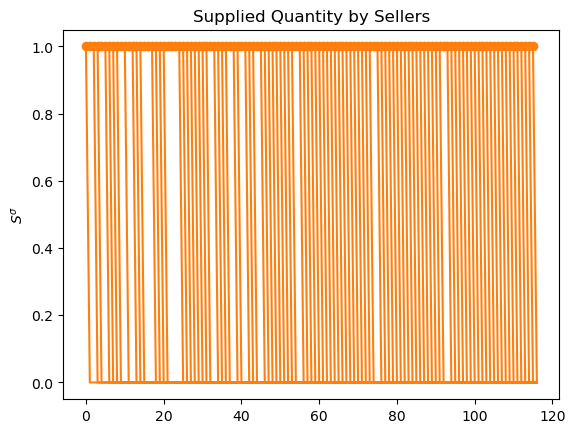

In [29]:
plt.plot(supply, c='C1')
plt.scatter(x=range(len(seller_supply)), y=seller_supply, c='C1')

plt.title('Supplied Quantity by Sellers')
plt.ylabel('$S^{\sigma}$')
#plt.yscale('log')

Text(0, 0.5, '$-S^{\\beta}$')

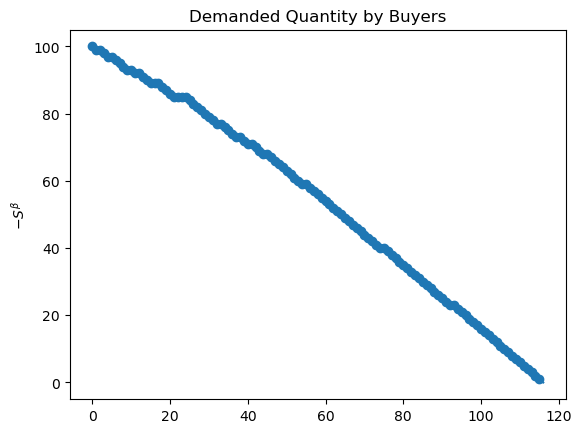

In [30]:
plt.plot(demand, c='C0')
plt.scatter(x=range(len(buyer_demand)), y=buyer_demand, c='C0')

plt.title('Demanded Quantity by Buyers')
plt.ylabel(r'$-S^{\beta}$')

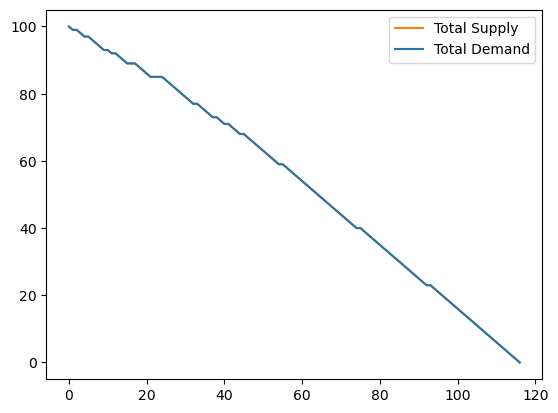

In [31]:
plt.plot(supply.sum(axis=1), c='C1', label='Total Supply')
plt.plot(demand.sum(axis=1), c='C0', label='Total Demand')
plt.legend()
#plt.yscale('log')

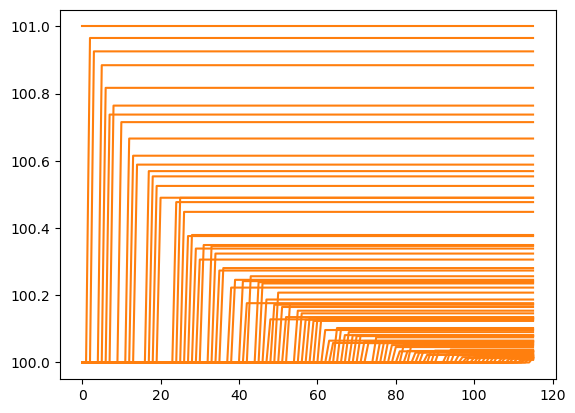

In [32]:
plt.plot(seller_money, c='C1')
plt.show()

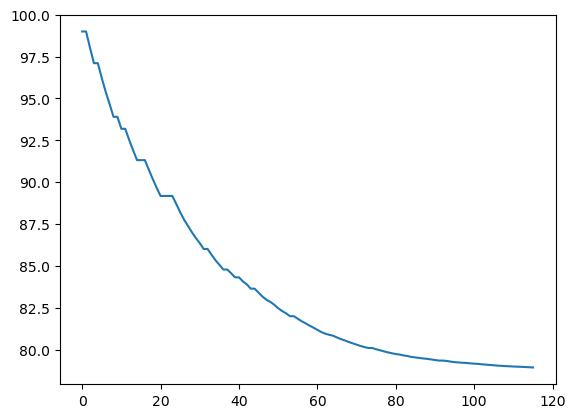

In [33]:
plt.plot(buyer_money, c='C0')
#plt.plot(buyer_money2, c='g', ls=':')
plt.show()

Text(0, 0.5, 'Mean Asking Price')

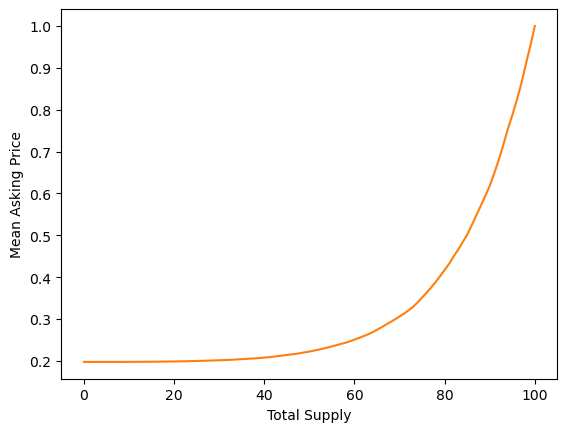

In [34]:
plt.plot(total_supply, mean_asks , c='C1')
plt.xlabel('Total Supply')
plt.ylabel('Mean Asking Price')

Text(0, 0.5, 'Mean Bidding Price')

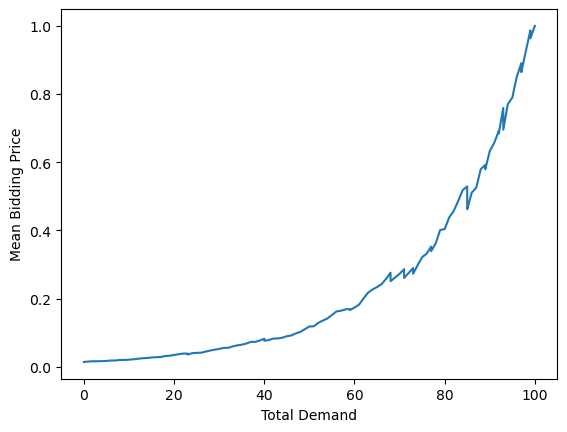

In [35]:
plt.plot(total_demand, mean_bids, c='C0')
plt.xlabel('Total Demand')
plt.ylabel('Mean Bidding Price')

In [36]:
#[plt.plot(buyer_money[:,n], buyer_money2[:-1,n]) for n in range(NB)]
#plt.show()

In [37]:
#buyer_money[:,n], buyer_money2[:-1,n]

Text(0, 0.5, '$p_{ask}$')

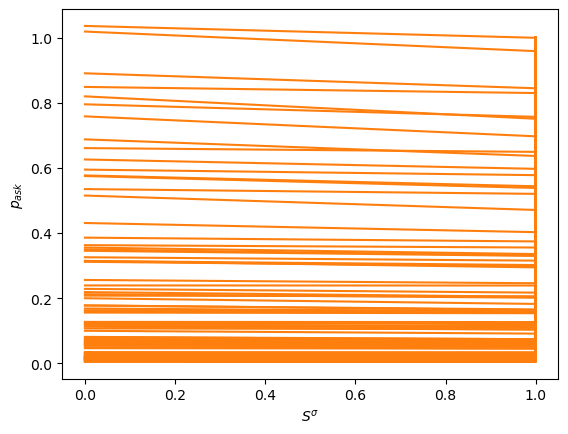

In [38]:
plt.plot(supply, asking_prices, c='C1')
plt.xlabel('$S^{\sigma}$')
plt.ylabel('$p_{ask}$')

Text(0, 0.5, '$p_{bid}$')

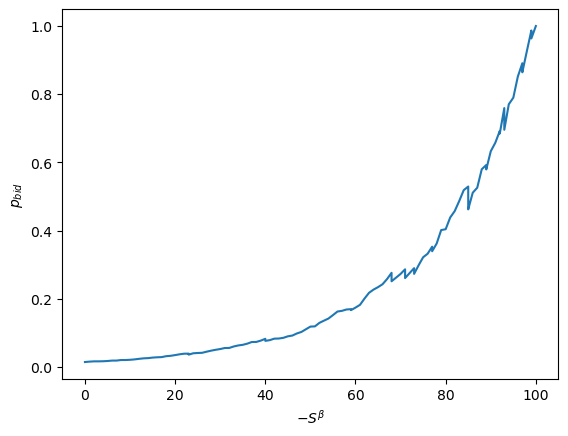

In [39]:
plt.plot(demand, bidding_prices)#, c='C0')
plt.xlabel(r'$-S^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

Text(0, 0.5, '$p_{bid}$')

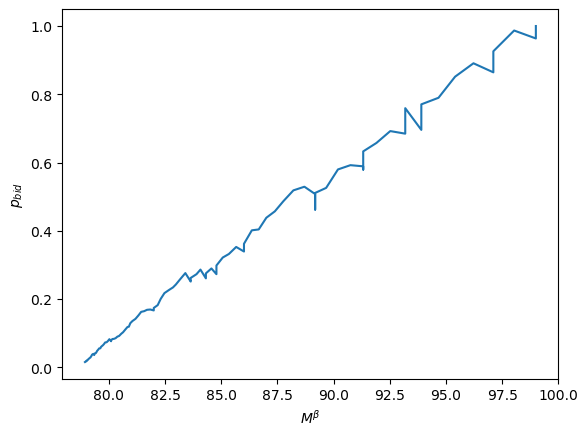

In [40]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
#plt.xscale('log')
#plt.yscale('log')

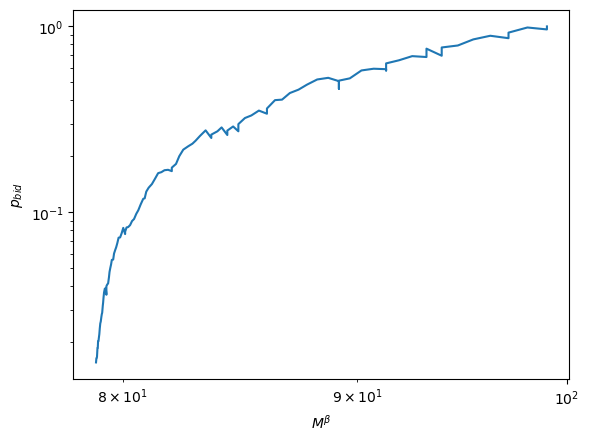

In [41]:
plt.plot(buyer_money, bidding_prices[:-1])#, c='C0')
plt.xlabel(r'$M^{\beta}$')
plt.ylabel('$p_{bid}$')
plt.xscale('log')
plt.yscale('log')

In [42]:
buyer_money.shape, bidding_prices.shape

((116, 1), (117, 1))

In [43]:
for agent in agent_list:
    
    print(agent.Q)

[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[100.   0.]


In [44]:
for agent in agent_list:
    
    print(agent.p_buy)

[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]

In [45]:
agent_data

array([[[0.        , 0.        ],
        [0.21858757, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.02190627, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.06218478, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.06853512, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.12458344, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.23905431, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.43096336, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.04626674, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.01374433, 0.        ],
        [0.        , 0.        ]],

       [[0.        , 0.        ],
        [0.01477504, 0.       

In [46]:
agent_Mdata

array([100.22287555, 100.03004064, 100.06411803, 100.06492675,
       100.13509719, 100.24599107, 100.47729945, 100.07483256,
       100.03029624, 100.01580932, 100.02088615, 100.12839098,
       100.01103198, 100.09816505, 101.        , 100.09037447,
       100.07843404, 100.71533186, 100.04586569, 100.05163692,
       100.09661819, 100.66650199, 100.0146754 , 100.02138529,
       100.01963675, 100.01913923, 100.20789803, 100.10254641,
       100.24209643, 100.01296411, 100.03425367, 100.06383291,
       100.1873525 , 100.52546534, 100.13087683, 100.13284662,
       100.96575479, 100.0384262 , 100.30627543, 100.1462445 ,
       100.01614849, 100.03349137, 100.2352361 , 100.0129646 ,
       100.34958279, 100.9258927 , 100.0805499 , 100.12365182,
       100.05436612, 100.01268235, 100.02422045, 100.34692911,
       100.37940714, 100.01868403, 100.25662609, 100.02439954,
       100.03522679, 100.01116643, 100.55390324, 100.61537476,
       100.884752  , 100.01127402, 100.01657075, 100.32